In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pip install -q ultralytics pandas scikit-learn huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.4 MB/s eta 0:00:00


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
labels_csv=pd.read_csv("/content/drive/MyDrive/Trash/dataset_labels.csv")

In [5]:
# Correct for inverted y-coordinates and potential swapping in labels_csv
# This transformation makes 'ymin' the top-most y-coordinate and 'ymax' the bottom-most y-coordinate
# assuming the original values were '1-y' and possibly swapped (bottom-y, top-y).

print("Applying y-coordinate correction to labels_csv...")

# Create temporary columns for the corrected values
labels_csv['temp_ymin'] = 1 - labels_csv['ymax']
labels_csv['temp_ymax'] = 1 - labels_csv['ymin']

# Overwrite the original 'ymin' and 'ymax' columns with the corrected values
labels_csv['ymin'] = labels_csv['temp_ymin']
labels_csv['ymax'] = labels_csv['temp_ymax']

# Drop the temporary columns
labels_csv = labels_csv.drop(columns=['temp_ymin', 'temp_ymax'])

print("Y-coordinates in labels_csv have been corrected.")
print("Labels CSV head after Y-coordinate correction:")
display(labels_csv.head())

Applying y-coordinate correction to labels_csv...
Y-coordinates in labels_csv have been corrected.
Labels CSV head after Y-coordinate correction:


,image_name,class_id,xmin,ymin,xmax,ymax
0,battery_frame_0000.jpg,1,0.6311,0.7694,1.0000,0.9389
1,battery_frame_0001.jpg,1,0.4462,0.7333,0.6578,1.0000
2,battery_frame_0001.jpg,0,0.7315,0.4742,0.9583,0.6382
3,battery_frame_0002.jpg,0,0.3213,0.0000,0.5543,0.3219
4,battery_frame_0002.jpg,0,0.7150,0.3506,0.9976,0.5472


In [6]:
image_dir = "/content/drive/MyDrive/Trash/images"

In [7]:
labels_csv.shape

(15637, 6)

In [8]:
import os

# Assuming image_dir is still defined from the previous cell
if 'image_dir' in locals() and os.path.exists(image_dir):
    all_files_in_dir = os.listdir(image_dir)
    print(f"Found {len(all_files_in_dir)} items in the directory: {image_dir}")
    print("Here are the first 10 items found in the directory (full path):")
    for i in range(min(10, len(all_files_in_dir))):
        print(os.path.join(image_dir, all_files_in_dir[i]))

    # Optionally, count only image files again
    image_files_only = [f for f in all_files_in_dir if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
    print(f"\nFound {len(image_files_only)} actual image files in the directory.")
    if len(image_files_only) < 7000:
        print("Warning: The number of image files found is less than the expected 7000.")
        print("Please ensure all your generated images are correctly placed and named in the specified Google Drive folder.")
else:
    print(f"Error: Image directory '{image_dir}' not found or not accessible. Please ensure it exists and Drive is mounted correctly.")

Found 7000 items in the directory: /content/drive/MyDrive/Trash/images
Here are the first 10 items found in the directory (full path):
/content/drive/MyDrive/Trash/images/battery_frame_6000.jpg
/content/drive/MyDrive/Trash/images/battery_frame_6001.jpg
/content/drive/MyDrive/Trash/images/battery_frame_6002.jpg
/content/drive/MyDrive/Trash/images/battery_frame_6003.jpg
/content/drive/MyDrive/Trash/images/battery_frame_6004.jpg
/content/drive/MyDrive/Trash/images/battery_frame_6005.jpg
/content/drive/MyDrive/Trash/images/battery_frame_6006.jpg
/content/drive/MyDrive/Trash/images/battery_frame_6007.jpg
/content/drive/MyDrive/Trash/images/battery_frame_6008.jpg
/content/drive/MyDrive/Trash/images/battery_frame_6009.jpg

Found 7000 actual image files in the directory.


### 1. Data Preparation for YOLO

First, we need to set up the directory structure that YOLO expects and create the label files in the YOLO format. The `labels_csv` contains bounding box coordinates in `xmin, ymin, xmax, ymax` format, which we need to convert to `center_x, center_y, width, height` and normalize.

In [9]:
import os
import shutil

# Define paths for the YOLO dataset structure
# Changed to local Colab filesystem
base_yolo_dir = '/content/yolo_dataset'
images_dir = os.path.join(base_yolo_dir, 'images')
labels_dir = os.path.join(base_yolo_dir, 'labels')

train_images_dir = os.path.join(images_dir, 'train')
train_labels_dir = os.path.join(labels_dir, 'train')
val_images_dir = os.path.join(images_dir, 'val')
val_labels_dir = os.path.join(labels_dir, 'val')

# Create directories if they don't exist
for d in [train_images_dir, train_labels_dir, val_images_dir, val_labels_dir]:
    os.makedirs(d, exist_ok=True)
    print(f"Created directory: {d}")

print("YOLO dataset directory structure created.")

Created directory: /content/yolo_dataset/images/train
Created directory: /content/yolo_dataset/labels/train
Created directory: /content/yolo_dataset/images/val
Created directory: /content/yolo_dataset/labels/val
YOLO dataset directory structure created.


In [10]:
import os
import shutil
from tqdm import tqdm # Import tqdm for the progress bar

# Ensure necessary variables are defined if this cell is run independently
if 'base_yolo_dir' not in locals():
    base_yolo_dir = '/content/yolo_dataset'
    images_dir = os.path.join(base_yolo_dir, 'images')
    labels_dir = os.path.join(base_yolo_dir, 'labels')
    train_images_dir = os.path.join(images_dir, 'train')
    val_images_dir = os.path.join(images_dir, 'val')

if 'local_images_source_dir' not in locals():
    local_images_source_dir = '/content/yolo_dataset_images_source'

if 'image_dir' not in locals(): # This is the Google Drive source path
    image_dir = "/content/drive/MyDrive/Trash/images" # Assuming this is the source based on prior cells

print("Checking local image source directory for image data...")

perform_copy = False
if not os.path.exists(local_images_source_dir) or not os.listdir(local_images_source_dir):
    print(f"Local image source directory '{local_images_source_dir}' is missing or empty. Preparing to copy images.")
    # Ensure directory exists for copying
    os.makedirs(local_images_source_dir, exist_ok=True)
    perform_copy = True
else:
    # Check if the number of files matches expectations
    actual_local_files = os.listdir(local_images_source_dir)
    print(f"DEBUG: Found {len(actual_local_files)} files in {local_images_source_dir}")
    # Expected number of images from context is 7000
    if len(actual_local_files) < 7000:
        print(f"Warning: Only {len(actual_local_files)} images found, expected 7000. Clearing and re-copying images to ensure completeness.")
        shutil.rmtree(local_images_source_dir) # Remove incomplete dir
        os.makedirs(local_images_source_dir) # Recreate empty dir
        perform_copy = True
    else:
        print(f"Local image source directory '{local_images_source_dir}' appears to be correctly populated with {len(actual_local_files)} images.")

if perform_copy:
    print(f"Copying images from Google Drive ({image_dir}) to local storage ({local_images_source_dir})... This may take a few minutes.")

    if not os.path.exists(image_dir):
        raise FileNotFoundError(f"Google Drive image source directory '{image_dir}' not found. Please ensure Drive is mounted and path is correct.")

    image_filenames_from_drive = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

    for img_file in tqdm(image_filenames_from_drive, desc="Copying Images"):
        shutil.copy(os.path.join(image_dir, img_file), os.path.join(local_images_source_dir, img_file))

    print(f"Finished copying {len(image_filenames_from_drive)} images to local storage.")
    print("Now proceeding with symbolic link creation.")


print("Re-creating symbolic links for images...")

# Ensure variables for train/val split are available
if 'unique_image_names' not in locals() or 'train_img_names' not in locals() or 'val_img_names' not in locals():
    print("Warning: `unique_image_names`, `train_img_names`, or `val_img_names` not found. Attempting to re-generate from `labels_csv`.")
    if 'labels_csv' not in locals():
        raise NameError("`labels_csv` is not defined. Please run previous cells that load the CSV (e.g., pvNSeT7VKBLD).")
    from sklearn.model_selection import train_test_split
    unique_image_names = list(labels_csv['image_name'].unique())
    train_img_names, val_img_names = train_test_split(unique_image_names, test_size=0.2, random_state=42)
    print(f"Successfully re-defined `unique_image_names` ({len(unique_image_names)}), `train_img_names` ({len(train_img_names)}), and `val_img_names` ({len(val_img_names)}).")


for img_name in unique_image_names:
    # Determine if it's a train or val image
    if img_name in train_img_names:
        target_image_dir = train_images_dir
    else:
        target_image_dir = val_images_dir

    # Create a symbolic link to the image file from the local source
    original_image_path = os.path.join(local_images_source_dir, img_name)
    target_image_filepath = os.path.join(target_image_dir, img_name)

    if not os.path.exists(original_image_path):
        print(f"Warning: Original image not found at {original_image_path}. This should not happen if copying was successful. Skipping symlink creation.")
    else:
        if os.path.exists(target_image_filepath) or os.path.islink(target_image_filepath):
            os.remove(target_image_filepath)
        os.symlink(original_image_path, target_image_filepath)

print("Finished re-creating symbolic links for images.")


Checking local image source directory for image data...
Local image source directory '/content/yolo_dataset_images_source' is missing or empty. Preparing to copy images.
Copying images from Google Drive (/content/drive/MyDrive/Trash/images) to local storage (/content/yolo_dataset_images_source)... This may take a few minutes.


Copying Images: 100%|██████████| 7000/7000 [03:22<00:00, 34.55it/s] 


Finished copying 7000 images to local storage.
Now proceeding with symbolic link creation.
Re-creating symbolic links for images...
Successfully re-defined `unique_image_names` (6350), `train_img_names` (5080), and `val_img_names` (1270).
Finished re-creating symbolic links for images.


Now, let's convert the bounding box format from `xmin, ymin, xmax, ymax` to YOLO's `center_x, center_y, width, height` (all normalized by image width/height). Since the `labels_csv` directly provides normalized coordinates, we just need to perform the transformation.

In [11]:
# Convert bounding box format and create YOLO label files

# Assuming image dimensions are consistent or not needed for normalization if already normalized.
# For YOLO format, coords are typically already normalized between 0 and 1.

def convert_bbox_to_yolo(xmin, ymin, xmax, ymax):
    # Calculate center_x, center_y, width, height
    center_x = (xmin + xmax) / 2
    center_y = (ymin + ymax) / 2
    width = xmax - xmin
    height = ymax - ymin
    return center_x, center_y, width, height

# Group labels by image to write all annotations for one image into a single file
image_groups = labels_csv.groupby('image_name')

print("Generating YOLO label files and creating symlinks for images...")

# Let's create a simple 80/20 train/val split of the unique images
from sklearn.model_selection import train_test_split
unique_image_names = list(labels_csv['image_name'].unique())

train_img_names, val_img_names = train_test_split(unique_image_names, test_size=0.2, random_state=42)

print(f"Total unique images: {len(unique_image_names)}")
print(f"Train images: {len(train_img_names)}")
print(f"Validation images: {len(val_img_names)}")

# Define the local source directory for the original images
local_images_source_dir = '/content/yolo_dataset_images_source'

for img_name in unique_image_names:
    df_for_image = image_groups.get_group(img_name)
    label_filename = img_name.replace('.jpg', '.txt').replace('.png', '.txt') # Assuming .jpg or .png

    yolo_annotations = []
    for index, row in df_for_image.iterrows():
        class_id = int(row['class_id'])
        center_x, center_y, width, height = convert_bbox_to_yolo(
            row['xmin'], row['ymin'], row['xmax'], row['ymax']
        )
        yolo_annotations.append(f"{class_id} {center_x:.6f} {center_y:.6f} {width:.6f} {height:.6f}")

    # Determine if it's a train or val image and save to appropriate directory
    if img_name in train_img_names:
        target_label_dir = train_labels_dir
        target_image_dir = train_images_dir
    else:
        target_label_dir = val_labels_dir
        target_image_dir = val_images_dir

    # Write the YOLO label file
    with open(os.path.join(target_label_dir, label_filename), 'w') as f:
        f.write('\n'.join(yolo_annotations))

    # Create a symbolic link to the image file from the local source
    original_image_path = os.path.join(local_images_source_dir, img_name) # Use local source
    target_image_filepath = os.path.join(target_image_dir, img_name)

    if not os.path.exists(original_image_path):
        print(f"Warning: Original image not found at {original_image_path}. Skipping symlink creation.")
    else:
        if os.path.exists(target_image_filepath) or os.path.islink(target_image_filepath):
            # If a file or symlink already exists at the target, remove it first
            os.remove(target_image_filepath) # os.remove works for both files and symlinks
        os.symlink(original_image_path, target_image_filepath)

print("Finished generating YOLO label files and creating symlinks for images.")

Generating YOLO label files and creating symlinks for images...
Total unique images: 6350
Train images: 5080
Validation images: 1270
Finished generating YOLO label files and creating symlinks for images.


Visualizing true labels for 5 random images from the training set...


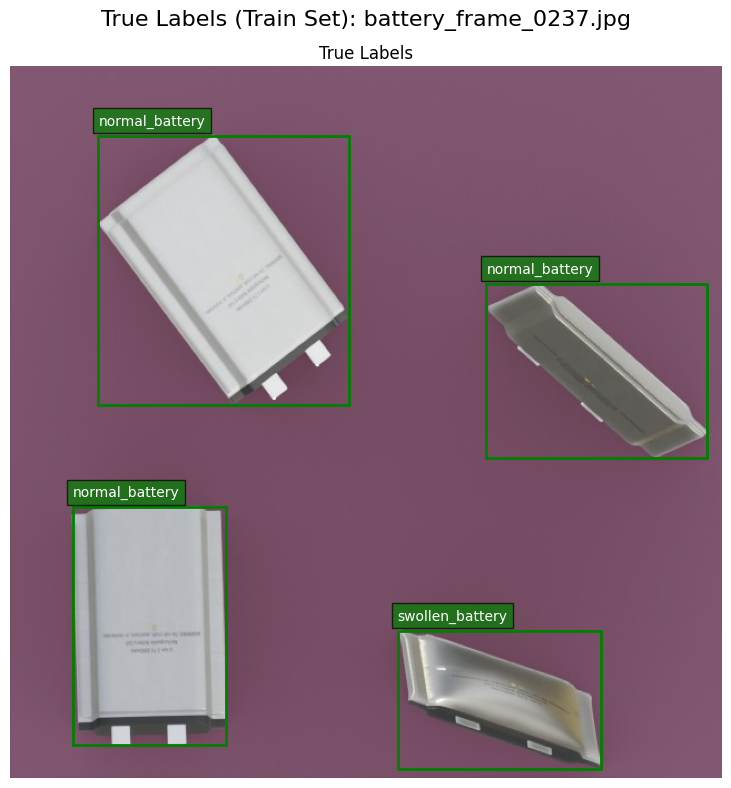

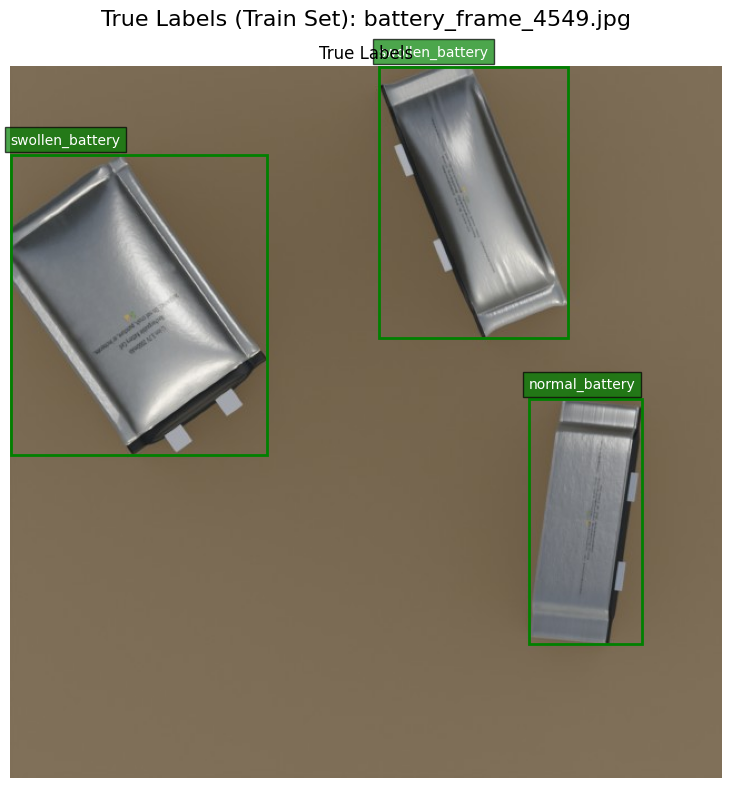

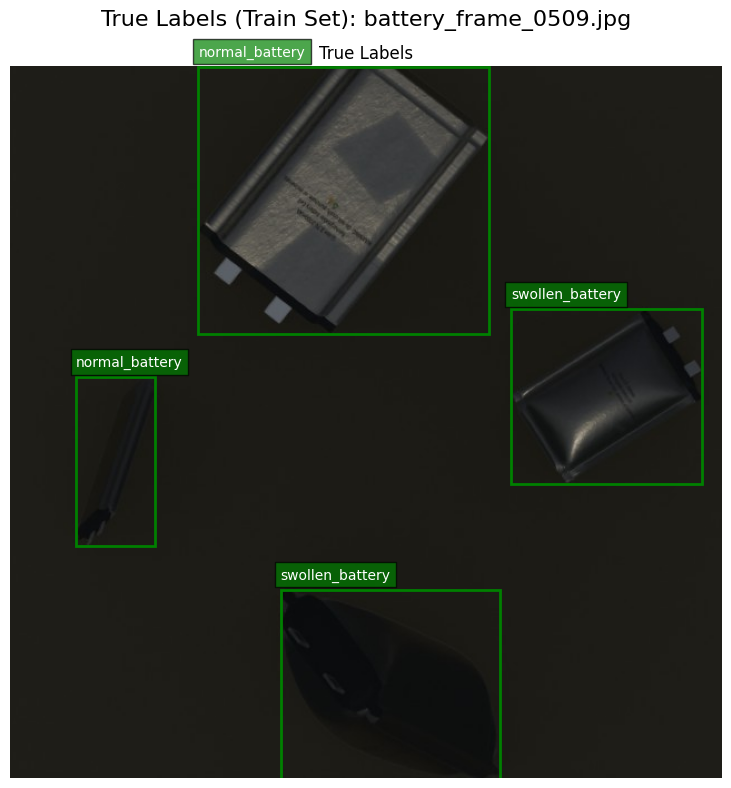

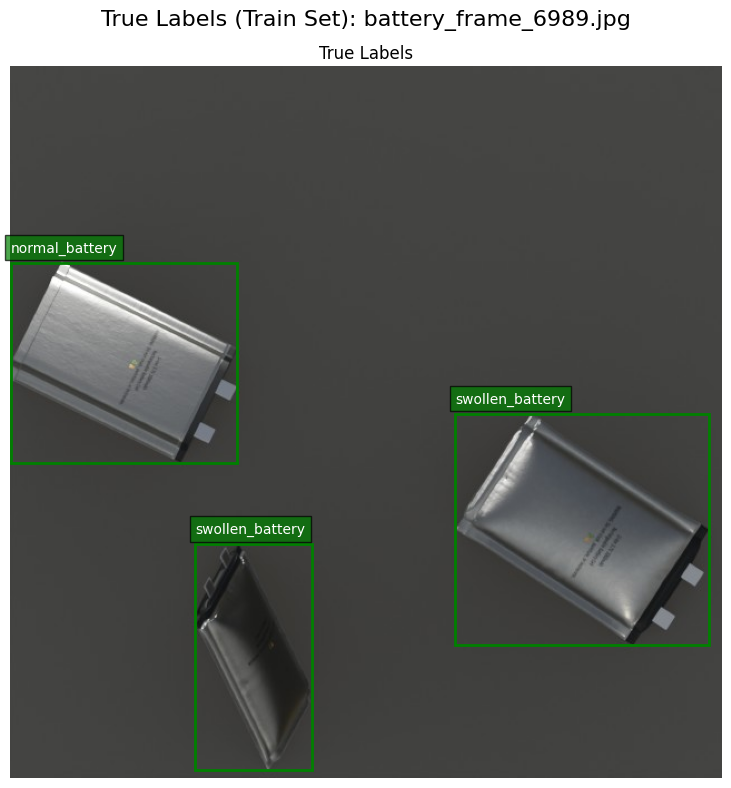

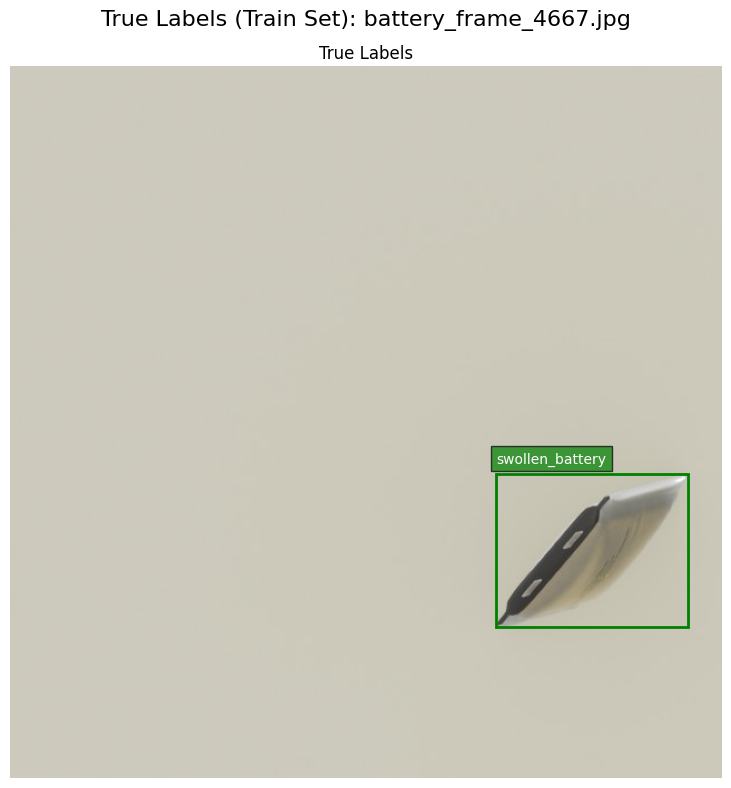

Visualizing true labels for 5 random images from the validation set...


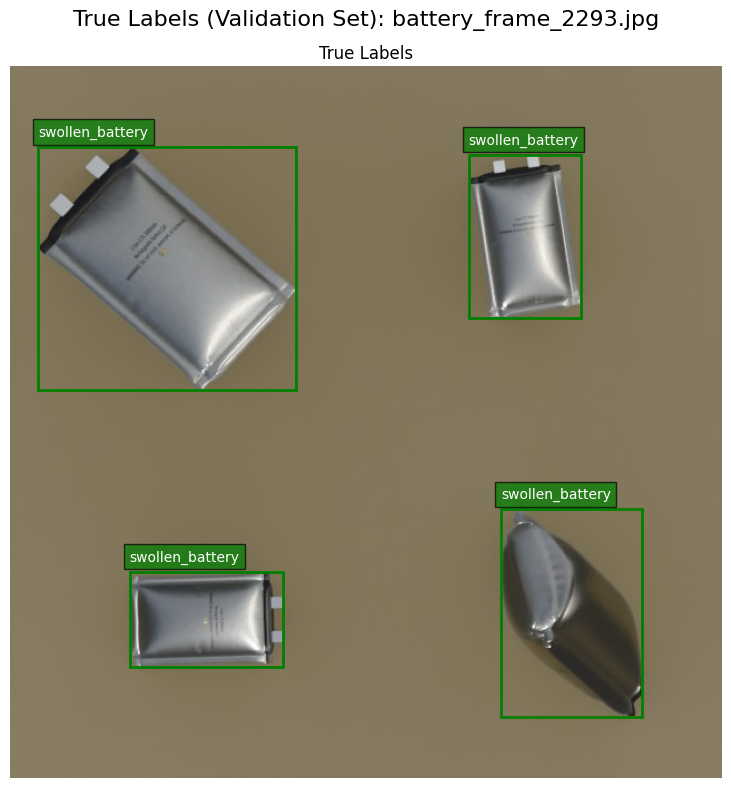

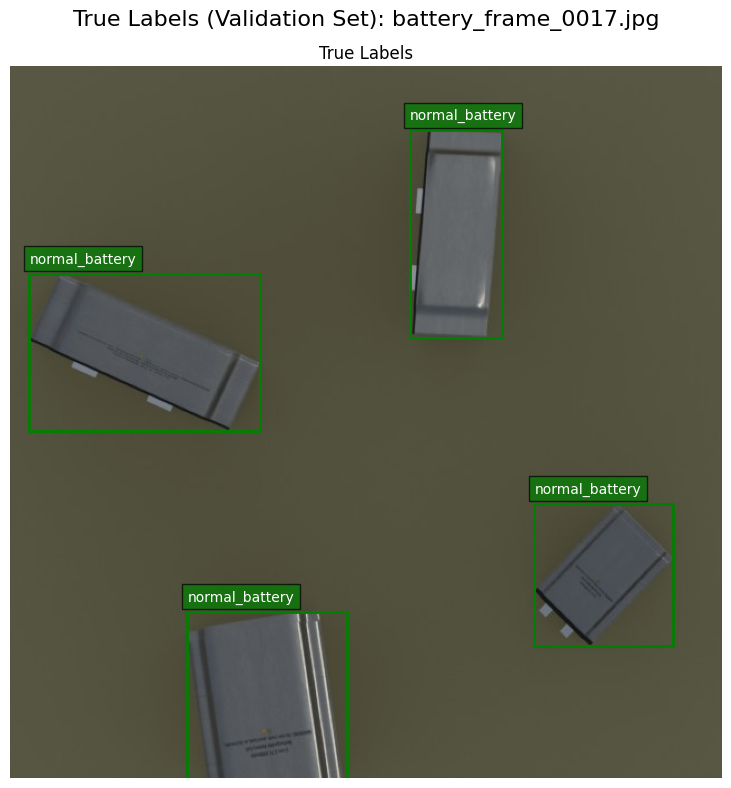

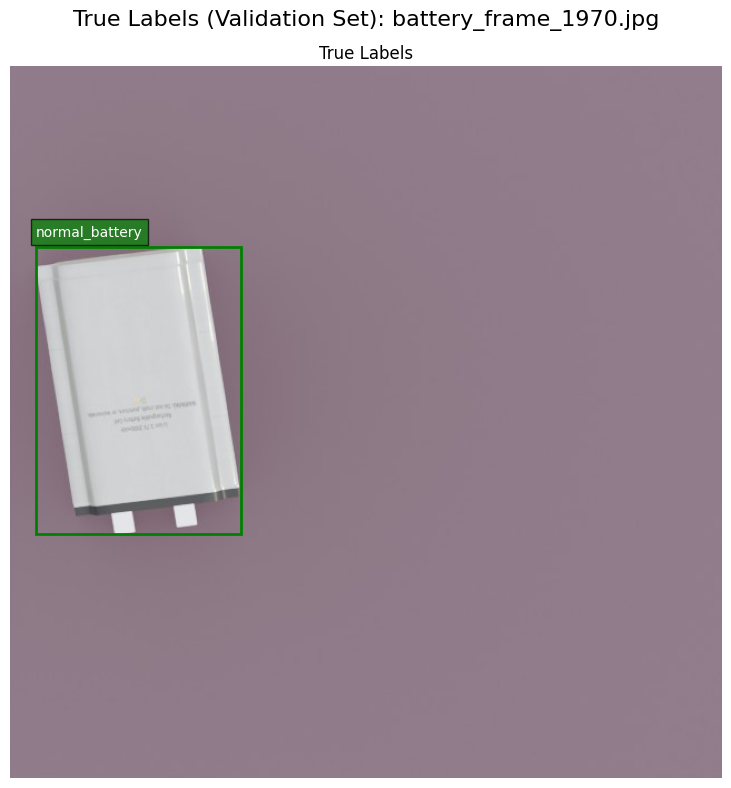

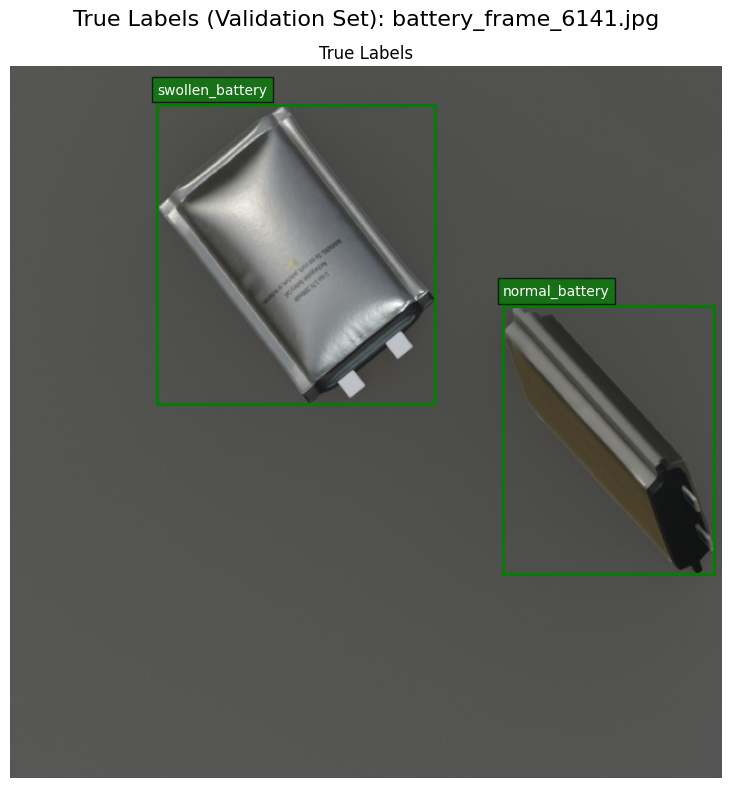

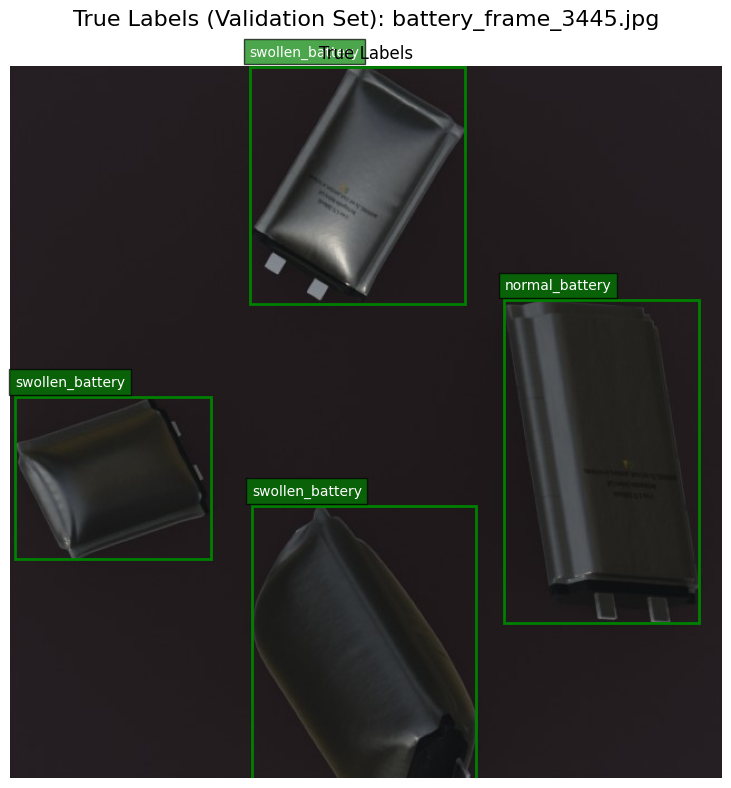

In [12]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define class names explicitly for visualization
class_names = {0: 'normal_battery', 1: 'swollen_battery'}

def convert_yolo_to_pixel(yolo_coords, img_w, img_h):
    # yolo_coords: (class_id, center_x, center_y, width, height) - normalized
    class_id, cx, cy, bw, bh = yolo_coords
    xmin = int((cx - bw/2) * img_w)
    ymin = int((cy - bh/2) * img_h)
    xmax = int((cx + bw/2) * img_w)
    ymax = int((cy + bh/2) * img_h)
    return (class_id, xmin, ymin, xmax, ymax)

def _visualize_single_image_true_labels(img_filename, is_train):
    """
    Internal helper to visualize true bounding box labels for a single image.
    """
    global train_images_dir, train_labels_dir, val_images_dir, val_labels_dir # class_names is now globally defined above

    if is_train:
        img_set_type = "Train Set"
        current_images_dir = train_images_dir
        current_labels_dir = train_labels_dir
    else:
        img_set_type = "Validation Set"
        current_images_dir = val_images_dir
        current_labels_dir = val_labels_dir

    img_path = os.path.join(current_images_dir, img_filename)

    if not os.path.exists(img_path):
        print(f"Error: Image not found in {img_set_type} directory: {img_path}. Skipping.")
        return

    # Read image using OpenCV
    image = cv2.imread(img_path)
    if image is None:
        print(f"Could not load image: {img_path}. Skipping.")
        return
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    # --- Get True Labels from YOLO .txt file ---
    true_boxes = [] # Format: (class_id, xmin, ymin, xmax, ymax)
    label_filename = img_filename.replace('.jpg', '.txt').replace('.png', '.txt')
    label_path = os.path.join(current_labels_dir, label_filename)

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = list(map(float, line.strip().split()))
                # Convert YOLO normalized (class_id, center_x, center_y, width, height) to pixel (class_id, xmin, ymin, xmax, ymax)
                class_id, xmin, ymin, xmax, ymax = convert_yolo_to_pixel((int(parts[0]), parts[1], parts[2], parts[3], parts[4]), w, h)
                true_boxes.append((class_id, xmin, ymin, xmax, ymax))
    else:
        print(f"Warning: No label file found for {img_filename} at {label_path}")

    # --- Plotting ---
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    fig.suptitle(f"True Labels ({img_set_type}): {img_filename}", fontsize=16)

    ax.imshow(image_rgb)
    ax.set_title('True Labels')
    for class_id, xmin, ymin, xmax, ymax in true_boxes:
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='green', facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, ymin - 10, class_names.get(class_id, f'Class {class_id}'), color='white', fontsize=10, bbox=dict(facecolor='green', alpha=0.7))
    ax.axis('off')

    plt.tight_layout()
    plt.show()

def visualize_random_true_labels_from_sets(num_train=5, num_val=5):
    """
    Visualizes true bounding box labels for random images from the training and validation sets.

    Args:
        num_train (int): The number of random training images to visualize.
        num_val (int): The number of random validation images to visualize.
    """
    global train_img_names, val_img_names # class_names is now globally defined above

    if not train_img_names:
        print("Error: `train_img_names` is empty. Please ensure data preparation (cell 488f2c76) has run.")
        return
    if not val_img_names:
        print("Error: `val_img_names` is empty. Please ensure data preparation (cell 488f2c76) has run.")
        return
    # Removed the 'class_names' check as it's now explicitly defined in this cell.

    # Select random images from the training set
    selected_train_images = random.sample(train_img_names, min(num_train, len(train_img_names)))
    print(f"Visualizing true labels for {len(selected_train_images)} random images from the training set...")
    for img_filename in selected_train_images:
        _visualize_single_image_true_labels(img_filename, is_train=True)

    # Select random images from the validation set
    selected_val_images = random.sample(val_img_names, min(num_val, len(val_img_names)))
    print(f"Visualizing true labels for {len(selected_val_images)} random images from the validation set...")
    for img_filename in selected_val_images:
        _visualize_single_image_true_labels(img_filename, is_train=False)

# Call the function to visualize 5 random training images and 5 random validation images
visualize_random_true_labels_from_sets(num_train=5, num_val=5)


### Addressing the `OSError: Operation not supported`

The error `OSError: [Errno 95] Operation not supported` indicates that `os.symlink` (symbolic linking) is not directly supported when trying to link files within the mounted Google Drive filesystem (`/content/drive/MyDrive`). Symbolic links are a powerful way to avoid duplicating data, but they require filesystem-level support which is not fully available for Google Drive in this context.

Also, as you noticed, copying thousands of files within Google Drive using `shutil.copy` is very slow. The Colab runtime's local storage (`/content/`) is significantly faster for read/write operations than Google Drive.

To optimize this process, we will adopt the following strategy:
1.  **Copy all original images from Google Drive to a temporary directory on the local Colab filesystem.** This will be the only slow copying step.
2.  **Reconfigure the YOLO dataset creation to use this local image source and build the YOLO dataset structure entirely within the local Colab filesystem.** This allows us to use symbolic links effectively within the local filesystem, and subsequent training will benefit from faster I/O.

Now that the images are copied to local storage, we will modify the previous cells to create the YOLO dataset structure and symbolic links *within the local filesystem*. This will make the next steps much faster.

### 2. Create `data.yaml` Configuration File

Now, we need to create a `data.yaml` file, which is crucial for YOLOv8 to understand the dataset structure, class names, and their distribution across training and validation sets.

In [ ]:
import os

# Define the content for data.yaml
data_yaml_content = f"""
train: {train_images_dir}
val: {val_images_dir}

nc: {len(class_names)}
names: {list(class_names.values())}
"""

# Define the path to save data.yaml
data_yaml_path = os.path.join(base_yolo_dir, 'data.yaml')

# Write the content to data.yaml
with open(data_yaml_path, 'w') as f:
    f.write(data_yaml_content)

print(f"Created data.yaml at: {data_yaml_path}")
print("Content of data.yaml:")
print(data_yaml_content)

### 3. Train YOLOv8 Model

Now we can use the `ultralytics` library to train a YOLOv8 model on our prepared dataset. We'll load a pre-trained `yolov8n.pt` (YOLOv8 nano) model for transfer learning. The `data.yaml` file we just created will tell the model where to find the images and labels, and what the class names are.

In [16]:
# Ensure ultralytics is installed, in case previous installation was interrupted
!pip install -q ultralytics

import os # Import os for file operations
from ultralytics import YOLO

# Load a pre-trained YOLOv8n model
# 'n' stands for nano, a small and fast model. You can try 's' (small), 'm' (medium), 'l' (large), or 'x' (extra large) for different sizes.
model = YOLO('yolov8n.pt')  # load a pretrained model

# Define the path to your data.yaml file
data_yaml_path = '/content/yolo_dataset/data.yaml'

# --- Create data.yaml content and write to file ---
# Define the content for data.yaml using variables from previous steps
data_yaml_content = f"""
train: {train_images_dir}
val: {val_images_dir}

nc: {len(class_names)}
names: {list(class_names.values())}
"""

# Write the content to data.yaml
with open(data_yaml_path, 'w') as f:
    f.write(data_yaml_content)

print(f"Created data.yaml at: {data_yaml_path}")
print("Content of data.yaml:")
print(data_yaml_content)
# --- End of data.yaml creation ---


# Train the model
# The 'data' argument points to your data.yaml file.
# 'epochs' specifies the number of training iterations.
# 'imgsz' (image size) defines the input image dimension for training.
# 'batch' defines the batch size.
# 'name' is the name of the run, results will be saved in runs/detect/name
results = model.train(data=data_yaml_path, epochs=50, imgsz=640, batch=32, name='battery_detector_v1')

print("Training complete! Results are typically saved in runs/detect/battery_detector_v1")

Created data.yaml at: /content/yolo_dataset/data.yaml
Content of data.yaml:

train: /content/yolo_dataset/images/train
val: /content/yolo_dataset/images/val

nc: 2
names: ['normal_battery', 'swollen_battery']

Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_rat

After training, the results (including weights, plots, etc.) will be saved in a directory like `runs/detect/battery_detector_v1`. You can then use the trained model for prediction or further evaluation.

In [24]:
import os
import shutil

# Define the source path of the best model
# This path is based on the default saving location of Ultralytics YOLO training runs
# Corrected path to match the actual output from the training run
source_model_path = '/content/runs/detect/battery_detector_v1-3/weights/best.pt'

# Define the destination path in Google Drive
# It's good practice to create a specific folder for models
drive_model_save_dir = '/content/drive/MyDrive/YOLOv8_Battery_Detector_Models'
destination_model_path = os.path.join(drive_model_save_dir, 'best_battery_detector_v1.pt')

# Create the destination directory in Google Drive if it doesn't exist
os.makedirs(drive_model_save_dir, exist_ok=True)

# Copy the model file
if os.path.exists(source_model_path):
    print(f"Copying model from {source_model_path} to {destination_model_path}...")
    shutil.copy(source_model_path, destination_model_path)
    print("Model saved successfully to Google Drive!")
    print(f"You can find it at: {destination_model_path}")
else:
    print(f"Error: Source model file not found at {source_model_path}. Please ensure training completed successfully and check the exact run name (e.g., battery_detector_v1, battery_detector_v1-2, etc.).")

Copying model from /content/runs/detect/battery_detector_v1-3/weights/best.pt to /content/drive/MyDrive/YOLOv8_Battery_Detector_Models/best_battery_detector_v1.pt...
Model saved successfully to Google Drive!
You can find it at: /content/drive/MyDrive/YOLOv8_Battery_Detector_Models/best_battery_detector_v1.pt


Loading model from: /content/runs/detect/battery_detector_v1-3/weights/best.pt
Visualizing predictions and true labels for 10 random images from the validation set...


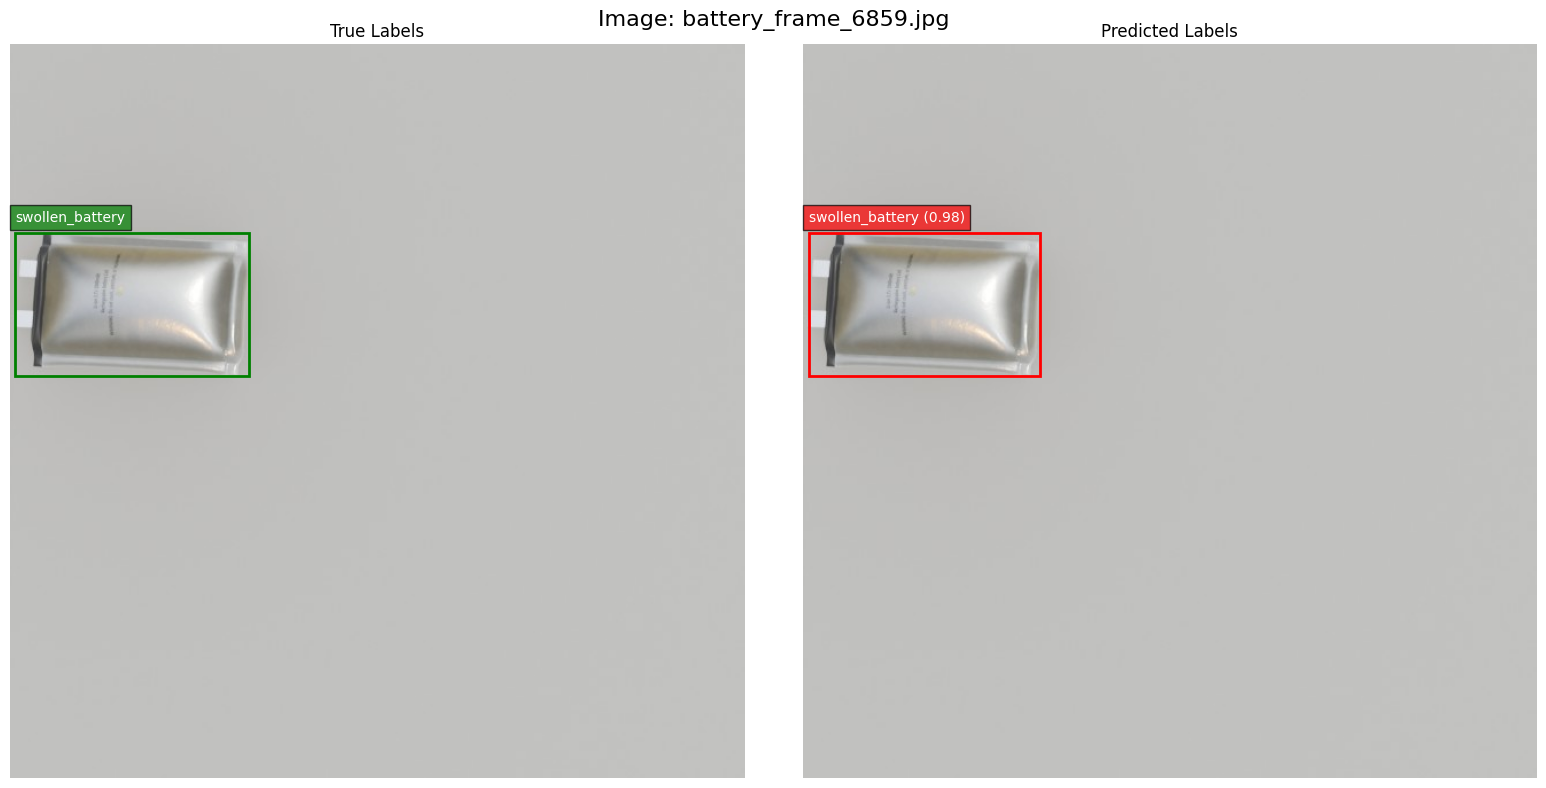

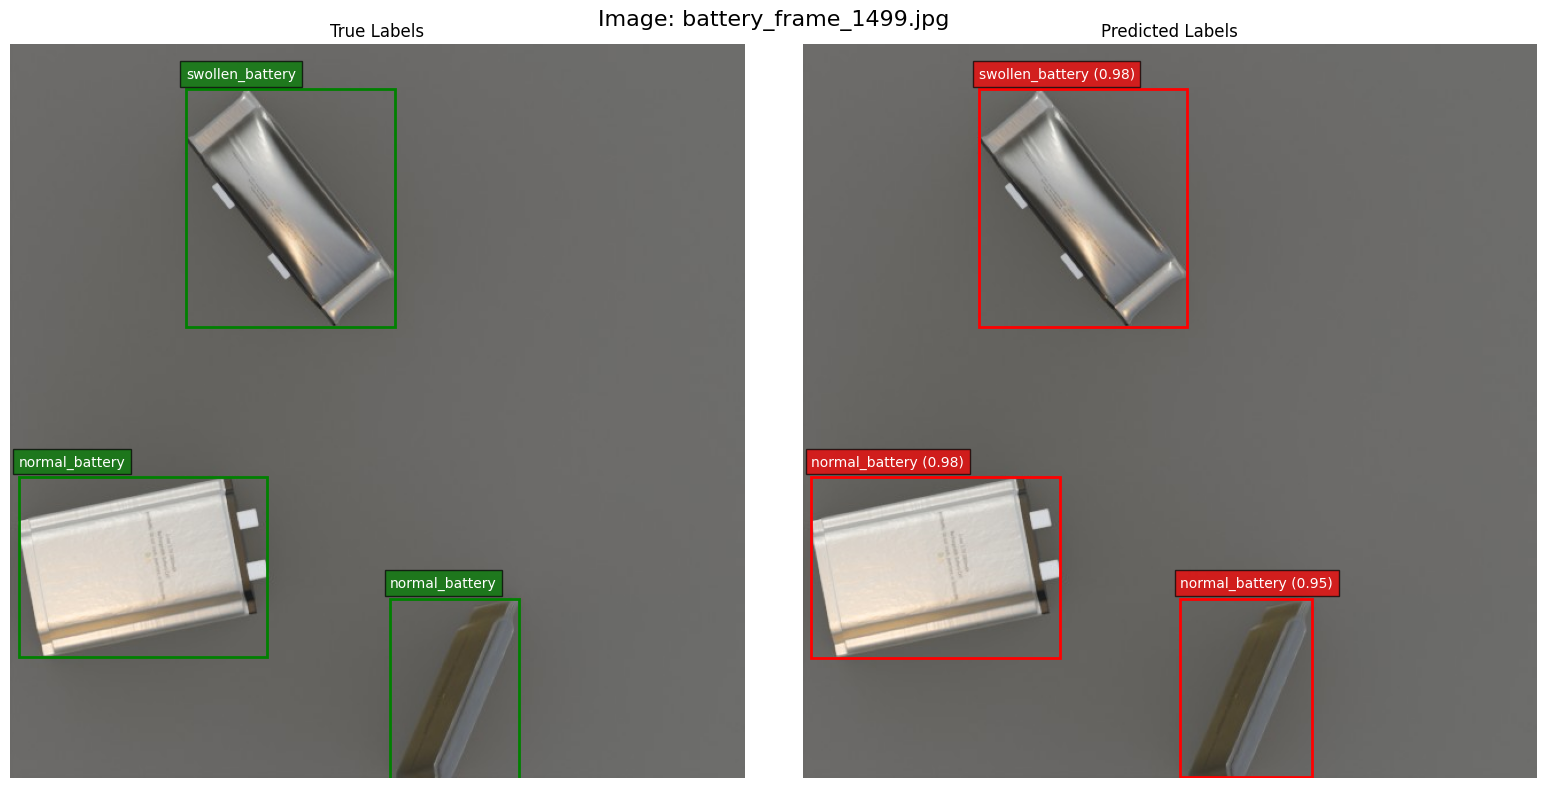

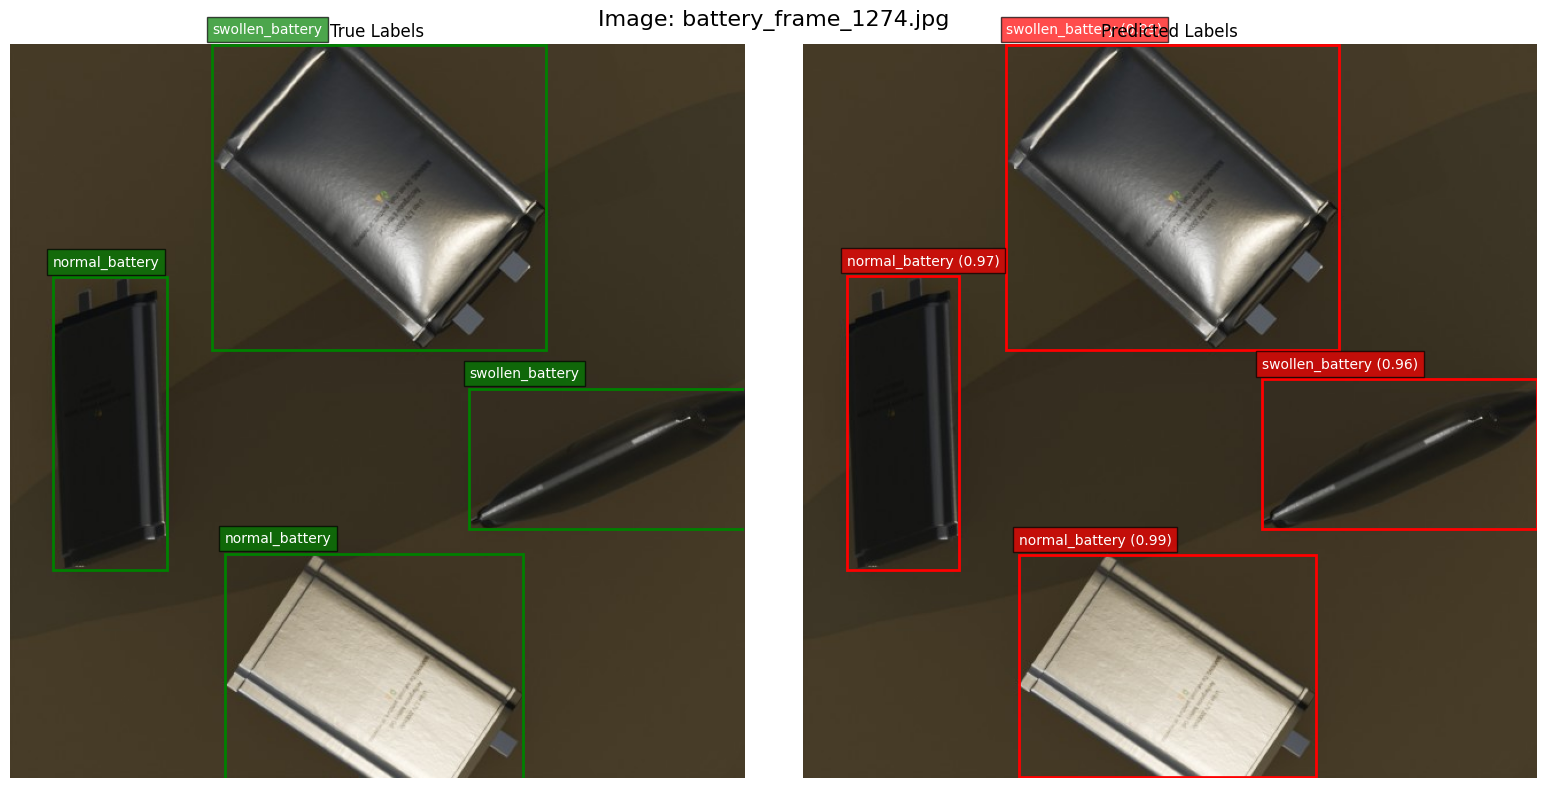

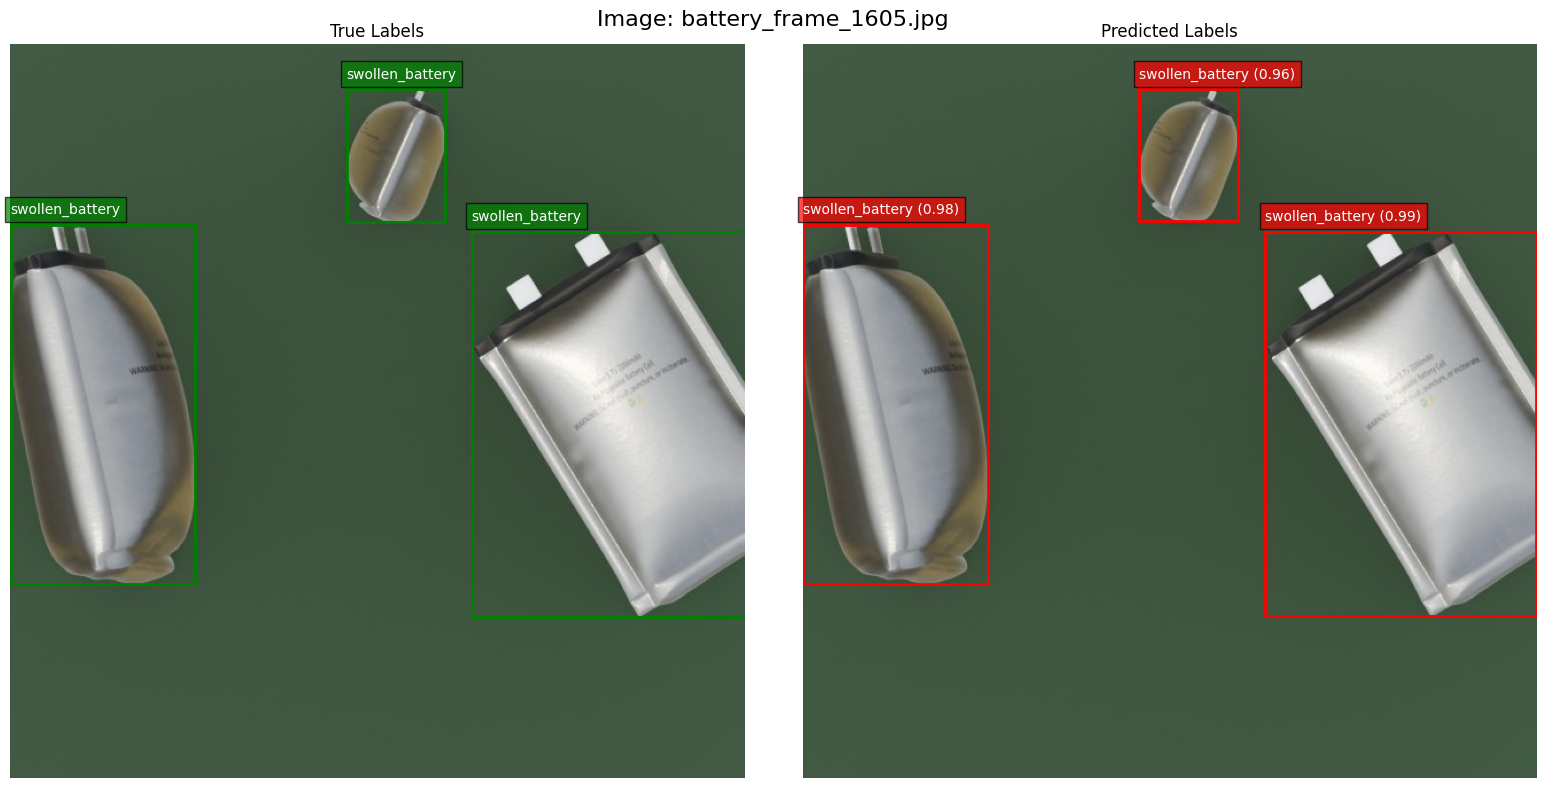

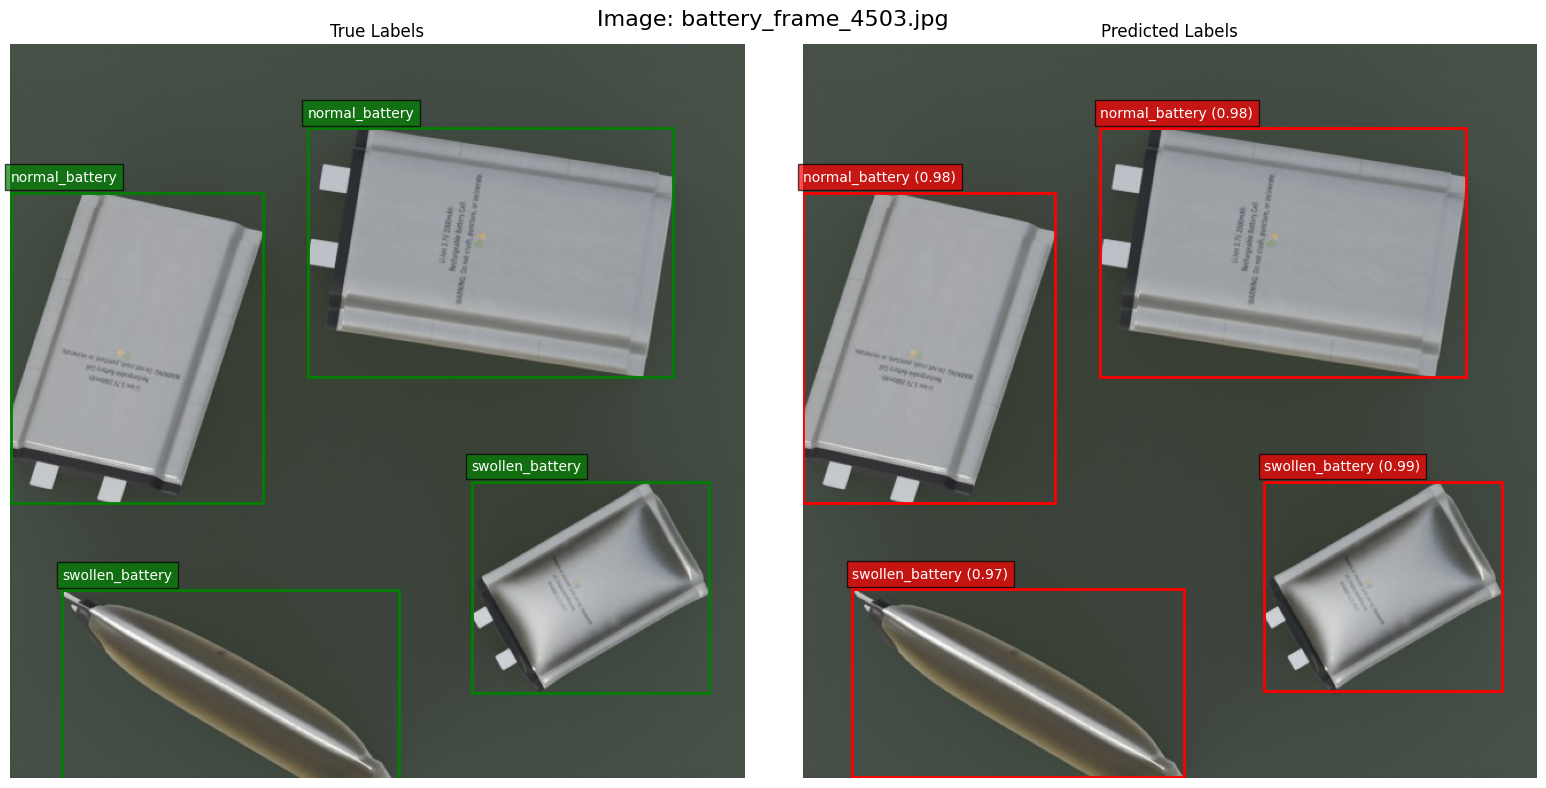

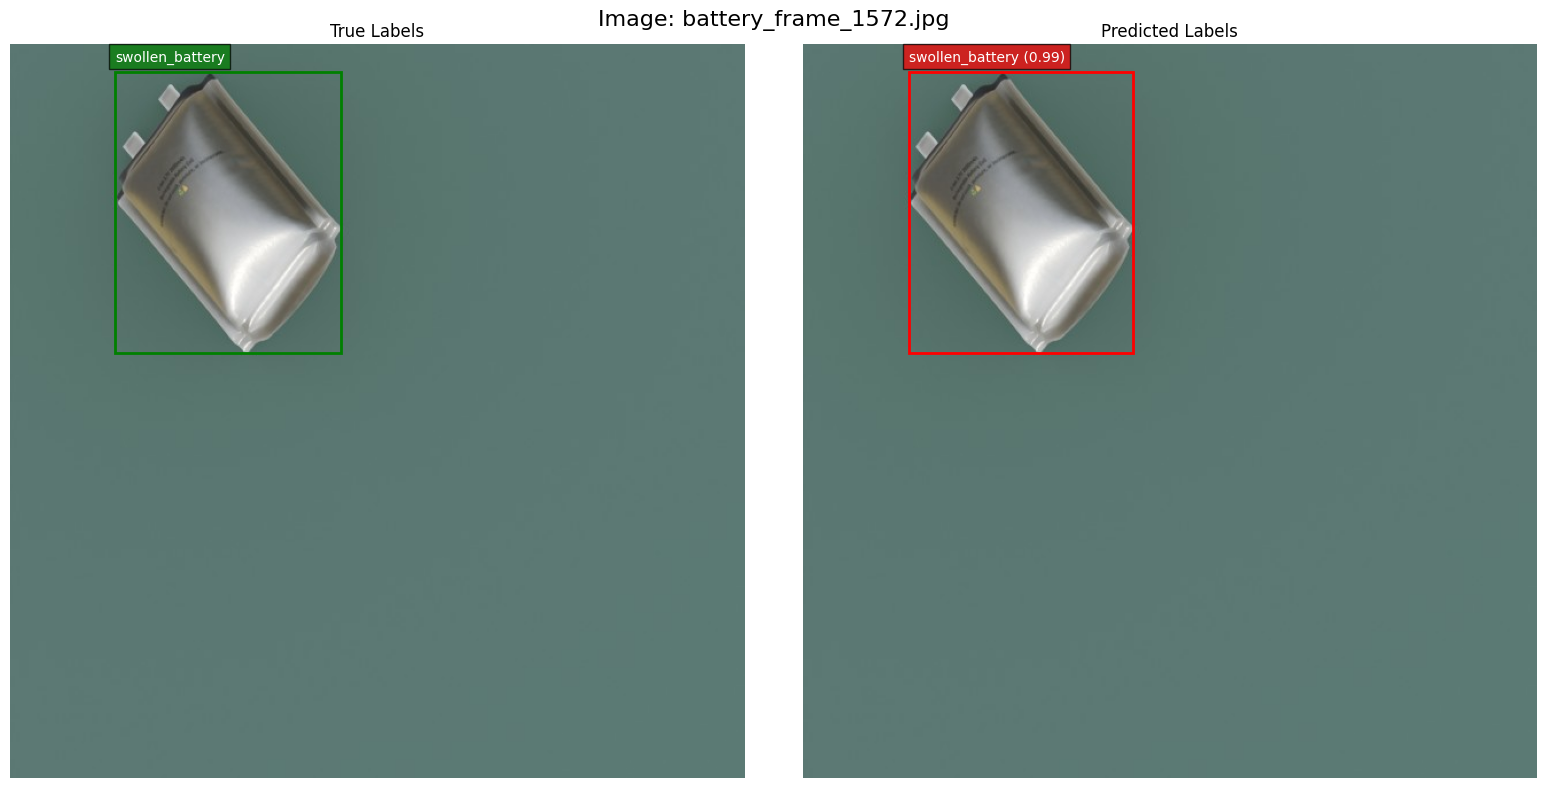

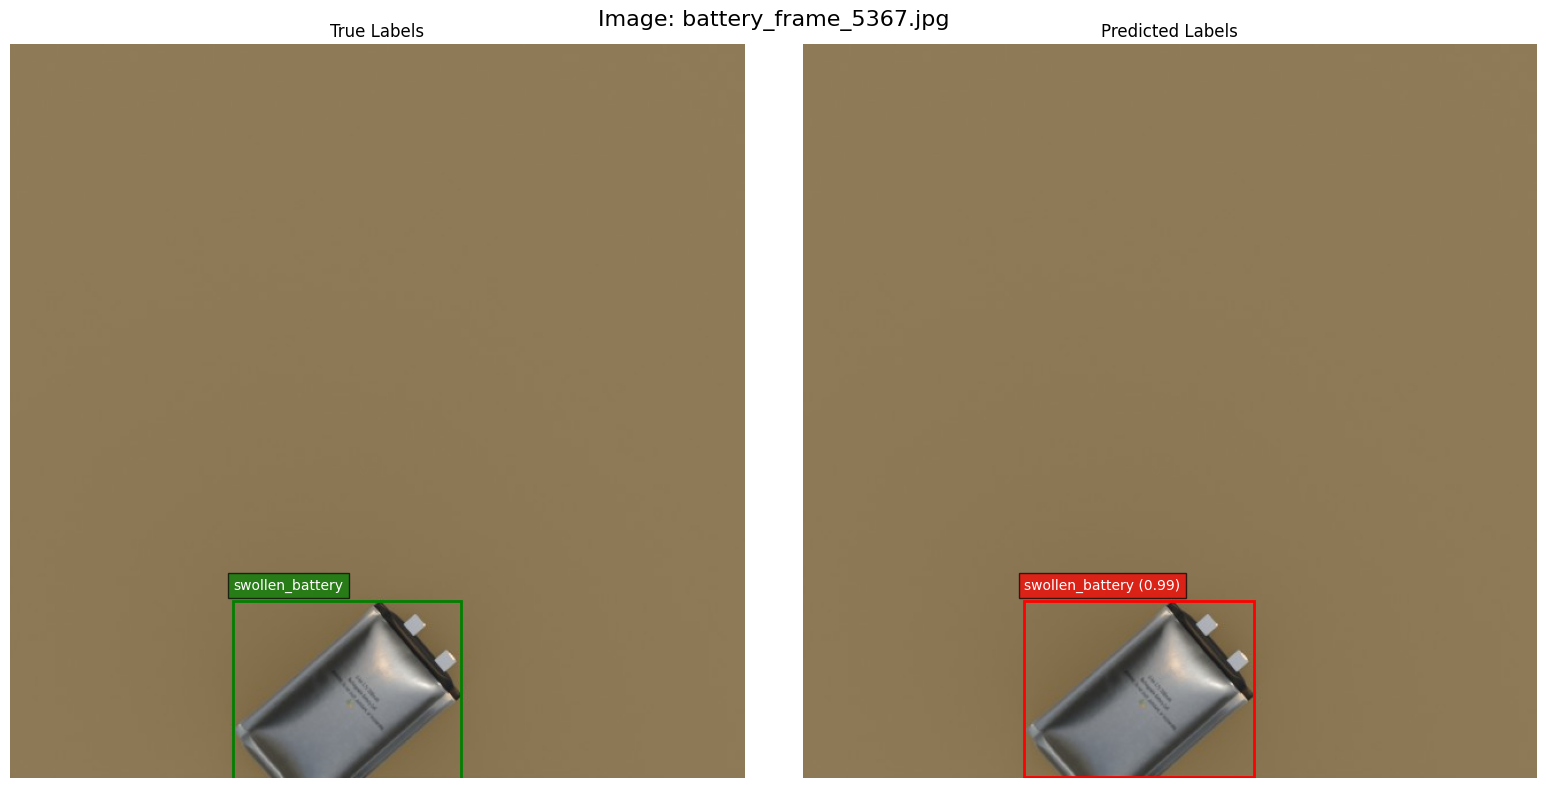

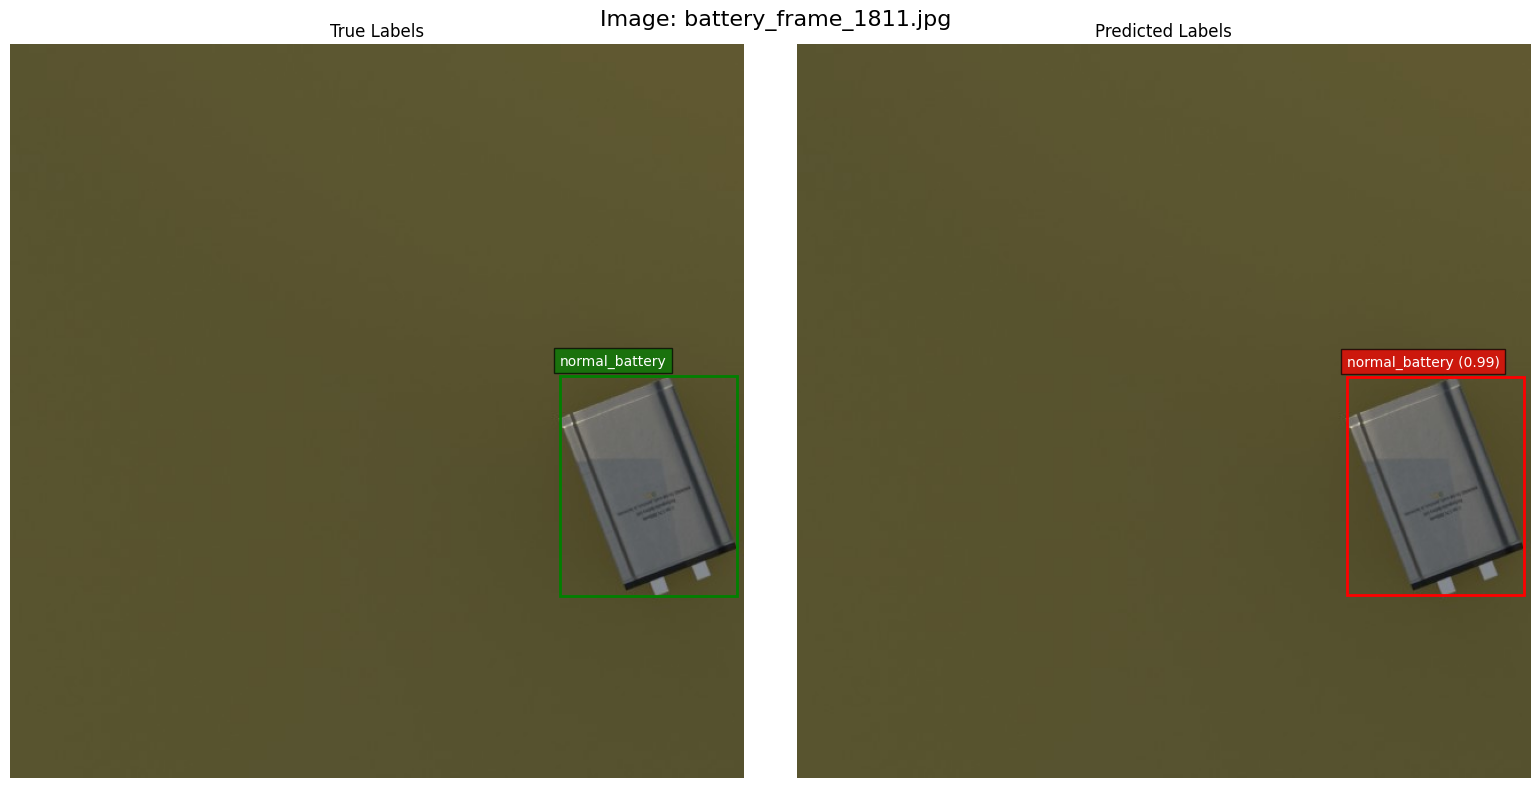

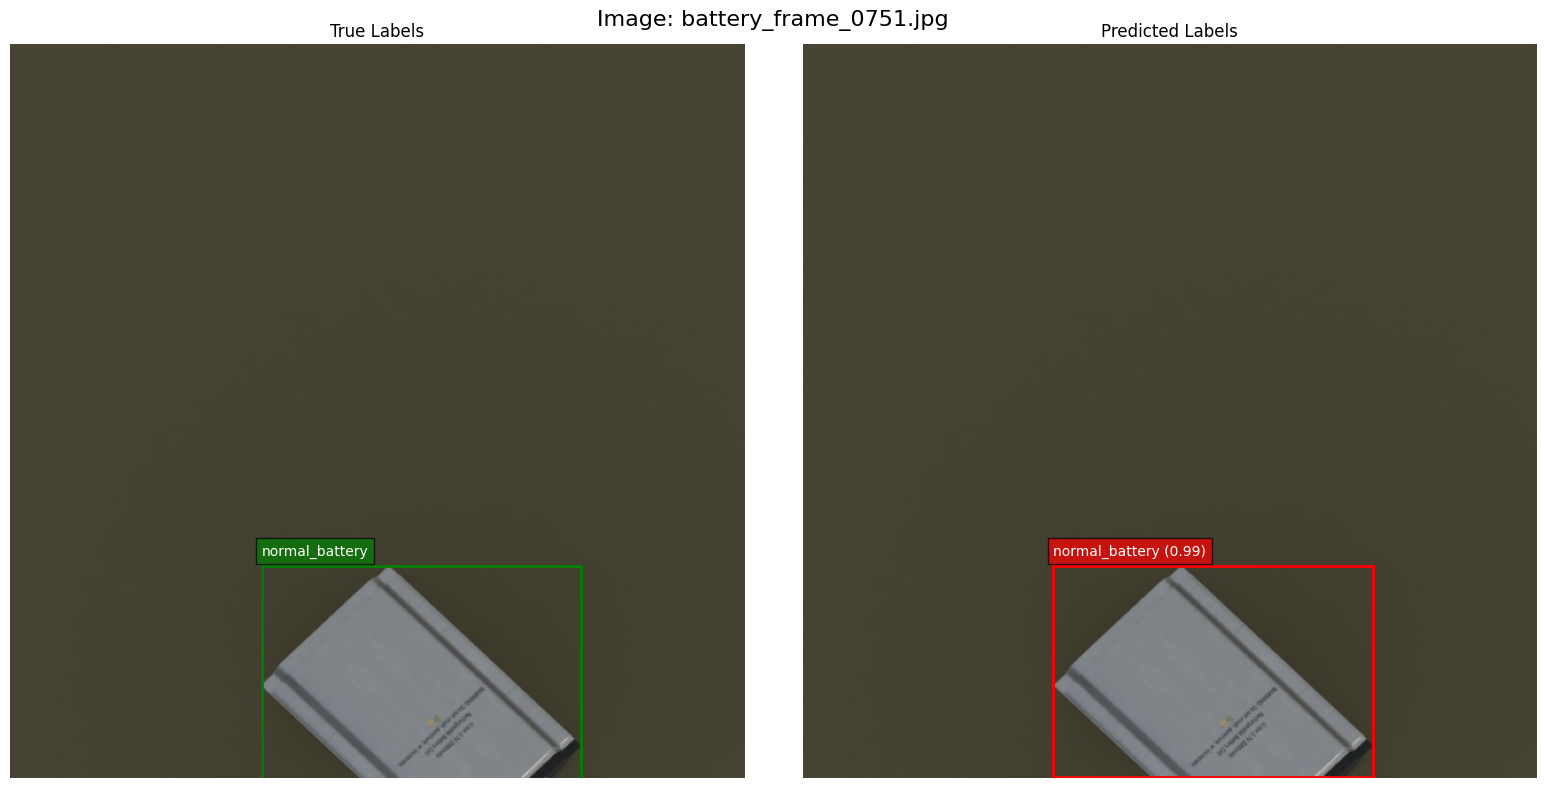

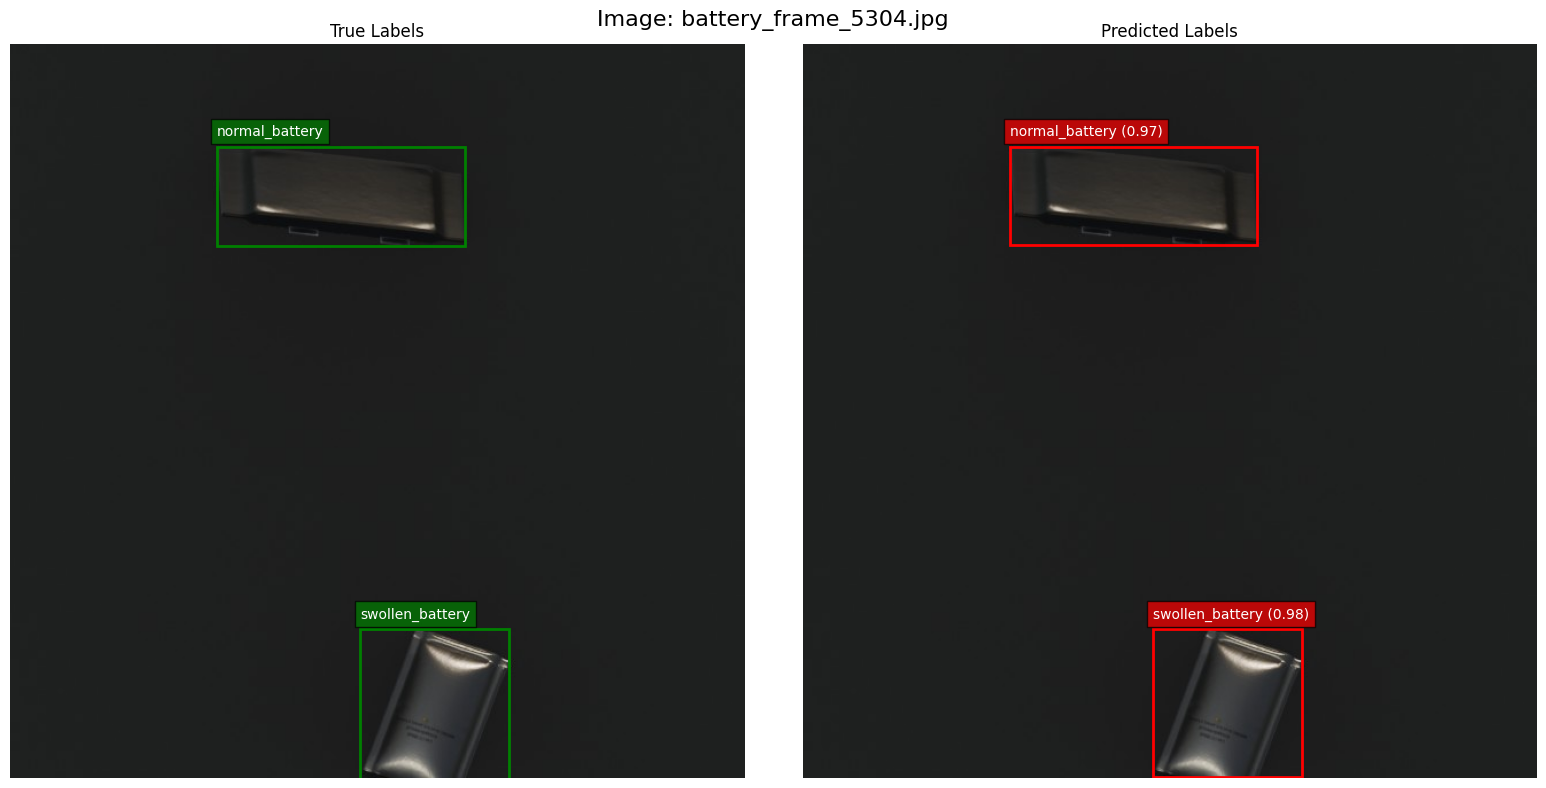

In [26]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO

# Define paths and class names. These are derived from previous cells.
# model_path refers to the 'best.pt' from the successful training run.
model_path = '/content/runs/detect/battery_detector_v1-3/weights/best.pt'
val_images_dir = '/content/yolo_dataset/images/val'
val_labels_dir = '/content/yolo_dataset/labels/val'
# class_names dictionary is also available from previous cells.
# class_names = {0: 'normal_battery', 1: 'swollen_battery'}

def convert_yolo_to_pixel(yolo_coords, img_w, img_h):
    # yolo_coords: (class_id, center_x, center_y, width, height) - normalized
    class_id, cx, cy, bw, bh = yolo_coords
    xmin = int((cx - bw/2) * img_w)
    ymin = int((cy - bh/2) * img_h)
    xmax = int((cx + bw/2) * img_w)
    ymax = int((cy + bh/2) * img_h)
    return (class_id, xmin, ymin, xmax, ymax)

# Load the trained YOLOv8 model
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Error: Trained model not found at {model_path}. Please ensure training completed successfully.")
print(f"Loading model from: {model_path}")
model = YOLO(model_path)

def visualize_predictions_and_true_labels(yolo_model, num_images=10):
    global val_img_names, val_images_dir, val_labels_dir, class_names

    if not val_img_names:
        print("Error: `val_img_names` is empty. Please ensure data preparation has run.")
        return

    # Select random images from the validation set
    selected_val_images = random.sample(val_img_names, min(num_images, len(val_img_names)))
    print(f"Visualizing predictions and true labels for {len(selected_val_images)} random images from the validation set...")

    for img_filename in selected_val_images:
        img_path = os.path.join(val_images_dir, img_filename)

        # Read image using OpenCV
        image = cv2.imread(img_path)
        if image is None:
            print(f"Could not load image: {img_path}. Skipping.")
            continue
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape

        # --- Get True Labels from YOLO .txt file ---
        true_boxes = [] # Format: (class_id, xmin, ymin, xmax, ymax)
        label_filename = img_filename.replace('.jpg', '.txt').replace('.png', '.txt')
        label_path = os.path.join(val_labels_dir, label_filename)

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = list(map(float, line.strip().split()))
                    # Convert YOLO normalized (class_id, center_x, center_y, width, height) to pixel (class_id, xmin, ymin, xmax, ymax)
                    class_id, xmin, ymin, xmax, ymax = convert_yolo_to_pixel((int(parts[0]), parts[1], parts[2], parts[3], parts[4]), w, h)
                    true_boxes.append((class_id, xmin, ymin, xmax, ymax))
        else:
            print(f"Warning: No label file found for {img_filename} at {label_path}")

        # --- Get Predicted Labels ---
        predicted_boxes = [] # Format: (class_id, xmin, ymin, xmax, ymax, confidence)
        results = yolo_model.predict(source=img_path, conf=0.25, iou=0.45, verbose=False) # Adjust conf and iou thresholds as needed

        if results and results[0].boxes:
            for box in results[0].boxes:
                xyxy = box.xyxy[0].cpu().numpy() # [xmin, ymin, xmax, ymax] in pixels
                conf = box.conf[0].cpu().numpy()
                cls = int(box.cls[0].cpu().numpy())
                xmin, ymin, xmax, ymax = map(int, xyxy)
                predicted_boxes.append((cls, xmin, ymin, xmax, ymax, conf))

        # --- Plotting ---
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        fig.suptitle(f"Image: {img_filename}", fontsize=16)

        # Plot True Labels
        axes[0].imshow(image_rgb)
        axes[0].set_title('True Labels')
        for class_id, xmin, ymin, xmax, ymax in true_boxes:
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='green', facecolor='none')
            axes[0].add_patch(rect)
            axes[0].text(xmin, ymin - 10, class_names.get(class_id, f'Class {class_id}'), color='white', fontsize=10, bbox=dict(facecolor='green', alpha=0.7))
        axes[0].axis('off')

        # Plot Predicted Labels
        axes[1].imshow(image_rgb)
        axes[1].set_title('Predicted Labels')
        for cls, xmin, ymin, xmax, ymax, conf in predicted_boxes:
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='red', facecolor='none')
            axes[1].add_patch(rect)
            axes[1].text(xmin, ymin - 10, f'{class_names.get(cls, f"Class {cls}")} ({conf:.2f})', color='white', fontsize=10, bbox=dict(facecolor='red', alpha=0.7))
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

# Call the function to visualize 10 random validation images
visualize_predictions_and_true_labels(model, num_images=10)

In [ ]:
import os
from ultralytics import YOLO
from IPython.display import Image, display
from google.colab import files
import io
import cv2
import numpy as np

# Define class names (consistent with previous cells)
class_names = {0: 'normal_battery', 1: 'swollen_battery'}

# Define the path to the best trained model
model_path = '/content/drive/MyDrive/YOLOv8_Battery_Detector_Models/best_battery_detector_v1.pt'

# Load the trained YOLOv8 model
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Error: Trained model not found at {model_path}. Please ensure training completed successfully.")
print(f"Loading model from: {model_path}")
model = YOLO(model_path)

print("Please upload an image for prediction:")

uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Uploaded file: {filename}')

    # Read image from bytes
    image_bytes = uploaded[filename]
    image_np = np.frombuffer(image_bytes, np.uint8)
    img = cv2.imdecode(image_np, cv2.IMREAD_COLOR)

    # Save the uploaded image temporarily to disk for YOLO.predict if it expects a path, or use it directly
    # For simplicity, we can save it and then use the path, or pass the numpy array directly
    temp_img_path = f'/content/{filename}'
    cv2.imwrite(temp_img_path, img) # Save to a temporary path

    # Perform prediction
    # YOLO.predict can take a file path, PIL Image, or NumPy array
    results = model.predict(source=temp_img_path, conf=0.5, iou=0.45, save=False, stream=False, verbose=False)

    # Display results (YOLOv8 results object has a convenient plot method)
    # The plot method returns an image with bounding boxes drawn
    if results:
        for r in results:
            im_array = r.plot()  # plot a BGR numpy array of predictions
            im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB) # Convert to RGB for display

            # Save the plotted image to display it
            plot_filename = f'/content/predicted_{filename}'
            cv2.imwrite(plot_filename, im_rgb)

            print(f"Predictions for {filename}:")
            display(Image(filename=plot_filename))

            # Print detected objects in text form
            if r.boxes and len(r.boxes) > 0:
                for box in r.boxes:
                    cls = int(box.cls[0].cpu().numpy())
                    conf = box.conf[0].cpu().numpy()
                    print(f"  - Detected: {class_names.get(cls, f'Class {cls}')} with confidence {conf:.2f}")
            else:
                print("  - No objects detected.")
    else:
        print(f"No results obtained for {filename}.")

    # Clean up the temporary image file
    if os.path.exists(temp_img_path):
        os.remove(temp_img_path)
    if os.path.exists(f'/content/predicted_{filename}'):
        os.remove(f'/content/predicted_{filename}')
